# Per-step monitoring: MSE & pinball loss (normal vs anomaly steps)

The per-step masked-loss trainer logs, at every logging/eval step, the mean over
**normal timesteps** (label 0) and over **anomaly timesteps** (label 1) of:

- `*_mse_normal_step` / `*_mse_anomaly_step` &mdash; forecast **MSE** (interpretable error)
- `*_normal_loss` / `*_anomaly_loss` &mdash; per-step **pinball** loss (the training objective)

with the standard HF prefixes: bare for **train**, `eval_val_` for **validation**, and
`eval_test_` for the **held-in portion of train** (the training-loss monitor).

During training you want, on every split: normal-step error trending **down**, anomaly-step
error trending **up** &mdash; a widening gap means the model is separating the two.

In [28]:
import json
import os
import matplotlib.pyplot as plt

# Output dir from run_finetune_smd.sh (OUTPUT_DIR). Edit if you ran with a different one.
OUTPUT_DIR = "./chronos2-single-stage_SMD_maskLossv2_v1"
STATE_PATH = os.path.join(OUTPUT_DIR, "trainer_state.json")

with open(STATE_PATH) as fh:
    log_history = json.load(fh)["log_history"]

print(f"Loaded {len(log_history)} log entries from {STATE_PATH}")

Loaded 1 log entries from ./chronos2-single-stage_SMD_maskLossv2_v1/trainer_state.json


In [29]:
def series(key):
    """Return (steps, values) for every log entry that carries `key`."""
    steps, vals = [], []
    for e in log_history:
        if key in e and e[key] is not None:
            steps.append(e["step"])
            vals.append(e[key])
    return steps, vals

def series_any(*keys):
    """Return the first non-empty series among `keys` (first prefix match wins)."""
    for k in keys:
        s, v = series(k)
        if s:
            return s, v
    return [], []

# (title, [prefix candidates]) for the three splits we monitor. HF prefixes the
# validation metrics as eval_val_* when a test set is also present, or plain eval_*
# when it is the only eval set — so we try both for the validation split.
PHASES = [
    ("Train",              [""]),
    ("Eval (validation)",  ["eval_val_", "eval_"]),
    ("Eval_test (held-in train)", ["eval_test_"]),
]

def phase_series(prefixes, suffix):
    return series_any(*[p + suffix for p in prefixes])

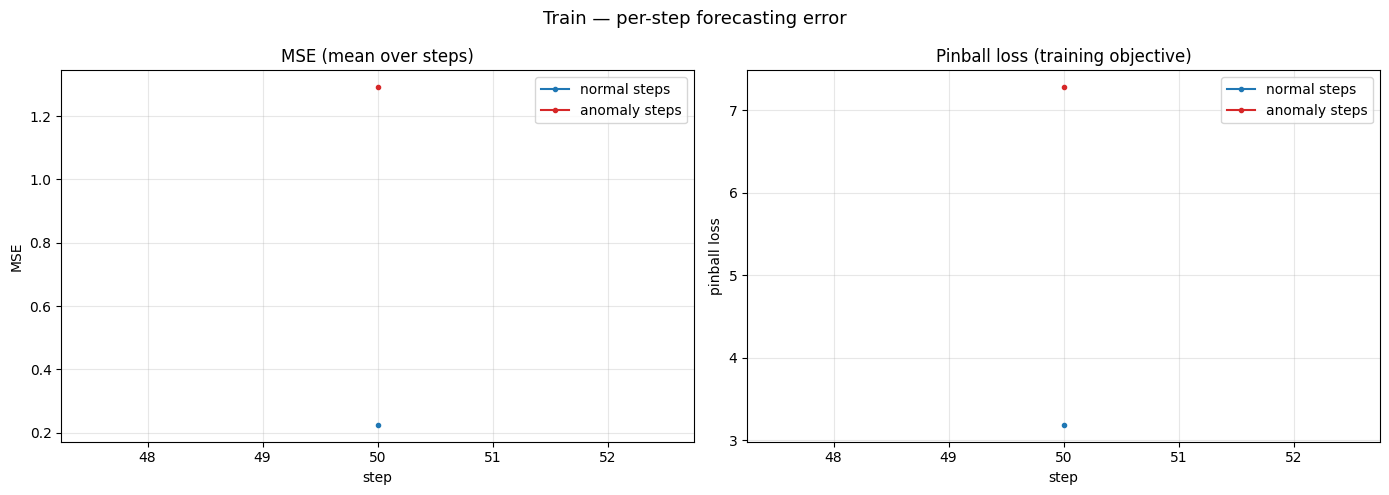

[Eval (validation)] no data found (prefixes tried: ['eval_val_', 'eval_']). Skipping — run with this split enabled to populate it.
[Eval_test (held-in train)] no data found (prefixes tried: ['eval_test_']). Skipping — run with this split enabled to populate it.


In [30]:
def plot_phase(title, prefixes):
    """One figure per split: MSE (left) and pinball loss (right), normal vs anomaly."""
    mse_n_x, mse_n_y = phase_series(prefixes, "mse_normal_step")
    mse_a_x, mse_a_y = phase_series(prefixes, "mse_anomaly_step")
    pin_n_x, pin_n_y = phase_series(prefixes, "normal_loss")
    pin_a_x, pin_a_y = phase_series(prefixes, "anomaly_loss")

    if not (mse_n_x or mse_a_x or pin_n_x or pin_a_x):
        print(f"[{title}] no data found (prefixes tried: {prefixes}). "
              "Skipping — run with this split enabled to populate it.")
        return

    fig, (ax_mse, ax_pin) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{title} — per-step forecasting error", fontsize=13)

    ax_mse.plot(mse_n_x, mse_n_y, marker=".", color="tab:blue",   label="normal steps")
    ax_mse.plot(mse_a_x, mse_a_y, marker=".", color="tab:red",    label="anomaly steps")
    ax_mse.set(xlabel="step", ylabel="MSE", title="MSE (mean over steps)")
    ax_mse.legend(); ax_mse.grid(True, alpha=0.3)

    ax_pin.plot(pin_n_x, pin_n_y, marker=".", color="tab:blue",   label="normal steps")
    ax_pin.plot(pin_a_x, pin_a_y, marker=".", color="tab:red",    label="anomaly steps")
    ax_pin.set(xlabel="step", ylabel="pinball loss", title="Pinball loss (training objective)")
    ax_pin.legend(); ax_pin.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

for title, prefixes in PHASES:
    plot_phase(title, prefixes)